# Complete Anomaly Detection on Facilities

## About this Notebook

### Objective

Identify facilities exhibiting abnormal NO₂ behavior relative to expected atmospheric conditions using engineered features and model predictions.

This notebook applies statistical and machine learning–based anomaly detection methods to detect facilities whose emissions patterns deviate significantly from modeled expectations.

---

### Inputs

- Feature-engineered anomaly dataset (from `FeaturesAnomalyDetection`)
- Facility-level predicted NO₂ (log scale)
- Residual features (observed vs predicted differences)
- Meteorological control variables
- Temporal and spatial context features

Primary data source:
`gs://msads-mba-capstone-team-1/AnomalyData/`

---

### Outputs

- Facility-level anomaly scores
- Flagged anomalous facilities (binary indicators or ranked risk scores)
- Model diagnostics and performance metrics
- Exported anomaly results saved to GCS

Example output:
`gs://msads-mba-capstone-team-1/AnomalyResults/facility_anomalies.csv`

---

### Detection Framework

Anomalies are identified using combinations of:

1. **Residual-Based Methods**
   - Large positive residuals (observed > predicted)
   - Standardized residual thresholds
   - Rolling deviation metrics

2. **Statistical Outlier Detection**
   - Z-score thresholds
   - Quantile-based cutoffs

3. **Machine Learning Methods**
   - Isolation Forest
   - Regression-based anomaly scoring

The goal is to separate expected atmospheric variability from abnormal emissions behavior.

---

### Key Notes

- Predictions are generated using the trained fusion NO₂ model.
- Residuals are computed on the log scale unless otherwise specified.
- Meteorological features help control for atmospheric dispersion effects.
- No future information should be used when computing temporal features.
- Anomaly detection is unsupervised or semi-supervised; flagged facilities indicate elevated risk, not confirmed violations.

---

### Pipeline Position

FusionNO2Model  
→ PredictFacilityNO2  
→ FeaturesAnomalyDetection  
→ AnomalyDetection  

This notebook produces facility-level anomaly indicators used for emissions verification and compliance screening.

## Config

In [50]:
CONFIG = {
    "anomaly_model_features_input_path":
        "gs://msads-mba-capstone-team-1/Data/Predictions/anomaly_model_features.csv",

    "satellite_features_intermediate_path":
        "gs://msads-mba-capstone-team-1/Data/TrainingData/facility_satellite_features.csv",

    "facility_input_path":
        "gs://msads-mba-capstone-team-1/Data/TrainingData/nei_2021_IL_nox_for_model.csv",

    "annual_anomaly_output":
        "gs://msads-mba-capstone-team-1/Data/Predictions/annual_anomaly_results_2021.csv",
}

## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gcsfs
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest

In [3]:
# Load Data
fs = gcsfs.GCSFileSystem()

with fs.open(CONFIG["anomaly_model_features_input_path"]) as f:
    anomaly_features_df = pd.read_csv(f)

with fs.open(CONFIG["facility_input_path"]) as f:
    facility_df = pd.read_csv(f)

In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
anomaly_features_df.head()

,facility_id,predicted_no2_log,predicted_no2,naics_code,lat,lon,GEOID10,reported_emissions,log_emissions,background_s5,facility_density_5km,nearby_emissions_5km,log_nearby_emissions_5km,boundary_layer_height,u_component_of_wind_10m,v_component_of_wind_10m,wind_speed,year,wind_dir,wind_dir_rad,wind_u_dir,wind_v_dir,log_blh,log_wind_speed,B1,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,B9,tropospheric_NO2_column_number_density,facility_contribution,log_contribution,log_predicted_no2,naics_2digit,sector_emission_mean,sector_emission_std,sector_emission_z,emission_percentile,no2_percentile
0,10691811,2.693790,14.795835,325180.0,41.512055,-87.617364,1.703183e+11,28.678680,3.390429,0.000080,79.0,973.928724,6.882364,535.416290,0.673510,0.530915,0.926306,2021.0,230.607684,4.024863,-0.583318,-0.702578,6.282809,0.638136,1772.995664,2022.568780,1433.859898,1569.942285,1450.444378,1454.033941,1626.181519,2133.683164,2358.417315,2281.009420,2516.132626,877.382177,0.000082,14.795755,2.759741,2.759746,32,24.283674,163.466845,0.026886,0.917796,0.996502
1,10692111,2.684778,14.669226,331110.0,41.656474,-87.625847,1.703182e+11,83.787327,4.440146,0.000076,99.0,2457.479937,7.807299,535.416290,0.673510,0.530915,0.926306,2021.0,230.607684,4.024863,-0.583318,-0.702578,6.282809,0.638136,1569.684444,1473.620416,1039.985330,1263.815556,1100.030715,1054.038967,1203.490984,1673.444835,1901.188417,1803.973258,2030.524297,686.915495,0.000105,14.669150,2.751694,2.751699,33,6.169623,31.847240,2.437188,0.960210,0.963271
2,10692311,2.605705,13.574336,332811.0,42.008329,-87.957168,1.703177e+11,5.168654,1.819481,0.000055,271.0,715.466854,6.574332,575.375710,0.687042,0.388107,0.849376,2021.0,240.118891,4.190865,-0.465104,-0.800729,6.347190,0.604490,2260.650652,2501.958778,1799.944395,2090.338523,1991.734282,2118.651246,2212.331554,2480.359282,2654.527580,2540.815391,2772.882562,1046.813167,0.000108,13.574281,2.679258,2.679262,33,6.169623,31.847240,-0.031430,0.738959,0.676432
3,10692411,2.680742,14.619081,517122.0,41.814630,-87.605669,1.703139e+11,0.086040,0.082538,0.000072,131.0,1053.513524,6.960835,520.401962,0.633031,0.438434,0.881732,2021.0,232.660595,4.060693,-0.524914,-0.679927,6.254914,0.611176,1921.280257,2056.036522,1562.329921,1673.908313,1539.131418,1537.451100,1678.256877,2068.093368,2281.314639,2147.246180,2412.638753,875.118582,0.000127,14.619009,2.748489,2.748493,51,1.633558,2.864471,-0.540246,0.102755,0.956712
4,10715911,2.520177,12.430801,324121.0,42.275124,-89.573565,1.717700e+11,4.709520,1.742135,0.000030,31.0,167.440178,5.126581,591.480972,0.591742,0.385130,0.746297,2021.0,242.478799,4.232053,-0.436997,-0.822424,6.360142,0.549755,2175.387910,2327.748937,1624.162515,1933.416464,1865.039642,1918.461422,2113.067284,2740.874089,3061.104648,2929.777187,3227.407807,1081.274301,0.000030,12.430771,2.597548,2.597551,32,24.283674,163.466845,-0.119744,0.722344,0.235899


In [5]:
anomaly_features_df.columns

Index(['facility_id', 'predicted_no2_log', 'predicted_no2', 'naics_code',
       'lat', 'lon', 'GEOID10', 'reported_emissions', 'log_emissions',
       'background_s5', 'facility_density_5km', 'nearby_emissions_5km',
       'log_nearby_emissions_5km', 'boundary_layer_height',
       'u_component_of_wind_10m', 'v_component_of_wind_10m', 'wind_speed',
       'year', 'wind_dir', 'wind_dir_rad', 'wind_u_dir', 'wind_v_dir',
       'log_blh', 'log_wind_speed', 'B1', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5',
       'B6', 'B7', 'B8', 'B8A', 'B9', 'tropospheric_NO2_column_number_density',
       'facility_contribution', 'log_contribution', 'log_predicted_no2',
       'naics_2digit', 'sector_emission_mean', 'sector_emission_std',
       'sector_emission_z', 'emission_percentile', 'no2_percentile'],
      dtype='object')

## Test Multivariate Predictive Power

In [6]:
# Scale Sentinel-2 Bands
for band in ["B1","B2","B3","B4","B5","B6",
             "B7","B8","B8A","B9","B11","B12"]:
    anomaly_features_df[f"{band}_scaled"] = anomaly_features_df[band] / 10000

In [7]:
# Log Transform S5
anomaly_features_df["log_s5"] = np.log1p(
    anomaly_features_df["tropospheric_NO2_column_number_density"]
)

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

model_features = [
    "log_s5",
    "log_predicted_no2",
    "log_contribution",
    "log_blh",
    "log_wind_speed",
    "facility_density_5km",
    "log_nearby_emissions_5km"
] + [f"{b}_scaled" for b in 
     ["B1","B2","B3","B4","B5","B6",
      "B7","B8","B8A","B9","B11","B12"]]

X = anomaly_features_df[model_features]
y = anomaly_features_df["log_emissions"]

rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=5,
    random_state=42
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

print("New CV R²:",
      cross_val_score(rf, X, y, cv=cv, scoring="r2").mean())

New CV R²: 0.20973931146968203


## Hybrid Anomaly Model

In [9]:
# Create Working Copy
import numpy as np
import pandas as pd

model_data_df = anomaly_features_df.copy()

In [10]:
# Basic Cleaning and Safety Imputation 
model_cols = [
    "log_s5",
    "log_predicted_no2",
    "log_contribution",
    "log_blh",
    "log_wind_speed",
    "facility_density_5km",
    "log_nearby_emissions_5km"
] + [
    "B1_scaled","B2_scaled","B3_scaled","B4_scaled",
    "B5_scaled","B6_scaled","B7_scaled","B8_scaled",
    "B8A_scaled","B9_scaled","B11_scaled","B12_scaled"
]

for col in model_cols:
    model_data_df[col] = model_data_df[col].fillna(
        model_data_df[col].median()
    )

### Model 1 - Supervised Expected Emissions Model

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

X = model_data_df[model_cols]
y = model_data_df["log_emissions"]

rf = RandomForestRegressor(
    n_estimators=600,
    min_samples_leaf=5,
    random_state=42
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
print("CV R²:",
      cross_val_score(rf, X, y, cv=cv, scoring="r2").mean())

rf.fit(X, y)

model_data_df["expected_log_emissions"] = rf.predict(X)

model_data_df["global_residual"] = (
    model_data_df["expected_log_emissions"]
    - model_data_df["log_emissions"]
)

CV R²: 0.20975407230339277


In [23]:
# Orthogonalize Residual
import statsmodels.api as sm

X_size = sm.add_constant(model_data_df["log_emissions"])
y_resid = model_data_df["global_residual"]

size_model = sm.OLS(y_resid, X_size).fit()

model_data_df["size_adjusted_residual"] = (
    y_resid - size_model.predict(X_size)
)

In [24]:
# Check size bias
print(
    model_data_df["size_adjusted_residual"]
    .corr(model_data_df["log_emissions"])
)

8.549522054112911e-16


In [26]:
#Sector-normalize that residual
model_data_df["size_adj_residual_z"] = (
    model_data_df
    .groupby("naics_2digit")["size_adjusted_residual"]
    .transform(lambda x: (x - x.mean()) / x.std())
)
#Min–max scale to 0–1
model_data_df["global_norm"] = (
    model_data_df["size_adj_residual_z"]
    - model_data_df["size_adj_residual_z"].min()
) / (
    model_data_df["size_adj_residual_z"].max()
    - model_data_df["size_adj_residual_z"].min()
)

### Model 2 - Peer-Conditional Residual

In [16]:
# PCA Stabilization for S2
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

s2_cols = [
    "B1_scaled","B2_scaled","B3_scaled","B4_scaled",
    "B5_scaled","B6_scaled","B7_scaled","B8_scaled",
    "B8A_scaled","B9_scaled","B11_scaled","B12_scaled"
]

scaler = StandardScaler()
s2_scaled = scaler.fit_transform(model_data_df[s2_cols])

pca = PCA(n_components=3, random_state=42)
s2_pca = pca.fit_transform(s2_scaled)

model_data_df["s2_pc1"] = s2_pca[:,0]
model_data_df["s2_pc2"] = s2_pca[:,1]
model_data_df["s2_pc3"] = s2_pca[:,2]

In [17]:
# Peer Space Features
peer_features = [
    "log_s5",
    "log_predicted_no2",
    "log_contribution",
    "log_blh",
    "log_wind_speed",
    "facility_density_5km",
    "log_nearby_emissions_5km",
    "s2_pc1","s2_pc2","s2_pc3"
]

In [18]:
# Fit nearest neighbors
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=20)
nbrs.fit(model_data_df[peer_features])

distances, indices = nbrs.kneighbors(model_data_df[peer_features])

peer_expected = []

for i, neighbors in enumerate(indices):
    peer_mean = model_data_df.iloc[neighbors]["log_emissions"].mean()
    peer_expected.append(peer_mean)

model_data_df["peer_expected_log_emissions"] = peer_expected

model_data_df["peer_residual"] = (
    model_data_df["peer_expected_log_emissions"]
    - model_data_df["log_emissions"]
)

In [19]:
# Sector normalize
model_data_df["peer_residual_z"] = (
    model_data_df.groupby("naics_2digit")["peer_residual"]
                 .transform(lambda x: (x - x.mean()) / x.std())
)

model_data_df["peer_norm"] = (
    model_data_df["peer_residual_z"]
    - model_data_df["peer_residual_z"].min()
) / (
    model_data_df["peer_residual_z"].max()
    - model_data_df["peer_residual_z"].min()
)

### Model 3 - Atmospheric Structural Anomaly

In [20]:
# Sector-Noramlized Feature Space
def safe_z(x):
    std = x.std()
    if std == 0 or np.isnan(std):
        return 0
    return (x - x.mean()) / std

atm_features = peer_features

for col in atm_features:
    model_data_df[col + "_z"] = (
        model_data_df.groupby("naics_2digit")[col]
                     .transform(safe_z)
    )

In [21]:
# Isolation Forest
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=500,
    contamination=0.05,
    random_state=42
)

z_cols = [col + "_z" for col in atm_features]

model_data_df["atm_raw"] = -iso.fit_predict(
    model_data_df[z_cols]
)

model_data_df["atm_norm"] = (
    model_data_df["atm_raw"]
    - model_data_df["atm_raw"].min()
) / (
    model_data_df["atm_raw"].max()
    - model_data_df["atm_raw"].min()
)

## Checks for Hybrid Decisions

### Robustness Checks

In [27]:
# Component Correlation Matrix
component_cols = ["global_norm","peer_norm","atm_norm"]

print(
    model_data_df[component_cols]
    .corr()
)

             global_norm  peer_norm  atm_norm
global_norm     1.000000   0.328045  0.025354
peer_norm       0.328045   1.000000 -0.063005
atm_norm        0.025354  -0.063005  1.000000


In [29]:
print(model_data_df["global_norm"]
      .corr(model_data_df["log_emissions"]))

-0.053038768295678454


### Sensitivity to Weights

In [30]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# Weight step (0.1 = 10% grid)
step = 0.1

weight_values = np.arange(0, 1 + step, step)

evaluation_results = []

# --- Baseline weights ---
baseline_weights = {"g": 0.5, "p": 0.3, "a": 0.2}

baseline_risk = (
    baseline_weights["g"] * model_data_df["global_norm"] +
    baseline_weights["p"] * model_data_df["peer_norm"] +
    baseline_weights["a"] * model_data_df["atm_norm"]
).rank(pct=True) * 100

baseline_top10 = set(
    baseline_risk.sort_values(ascending=False)
                 .head(10)
                 .index
)

for g in weight_values:
    for p in weight_values:
        a = 1 - g - p
        
        # skip invalid combos
        if a < 0 or a > 1:
            continue
        
        risk = (
            g * model_data_df["global_norm"] +
            p * model_data_df["peer_norm"] +
            a * model_data_df["atm_norm"]
        )
        
        risk_rank = risk.rank(pct=True) * 100
        
        # --- Metric 1: Spearman vs baseline ---
        spearman_corr = spearmanr(baseline_risk, risk_rank)[0]
        
        # --- Metric 2: Correlation with global ---
        corr_global = risk_rank.corr(model_data_df["global_norm"])
        
        # --- Metric 3: Correlation with peer ---
        corr_peer = risk_rank.corr(model_data_df["peer_norm"])
        
        # --- Metric 4: Correlation with atmospheric ---
        corr_atm = risk_rank.corr(model_data_df["atm_norm"])
        
        # --- Metric 5: Top-10 overlap ---
        top10_current = set(
            risk_rank.sort_values(ascending=False)
                     .head(10)
                     .index
        )
        
        overlap = len(baseline_top10 & top10_current)
        
        # --- Metric 6: Residual concentration ---
        top_decile_mask = risk_rank >= 90
        
        mean_residual_top = model_data_df.loc[
            top_decile_mask, 
            "size_adjusted_residual"
        ].mean()
        
        evaluation_results.append({
            "w_global": round(g,2),
            "w_peer": round(p,2),
            "w_atm": round(a,2),
            "spearman_vs_baseline": round(spearman_corr,3),
            "corr_with_global": round(corr_global,3),
            "corr_with_peer": round(corr_peer,3),
            "corr_with_atm": round(corr_atm,3),
            "top10_overlap": overlap,
            "mean_size_adj_resid_top_decile": round(mean_residual_top,4)
        })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df.sort_values(
    "mean_size_adj_resid_top_decile",
    ascending=False
).head(15)

,w_global,w_peer,w_atm,spearman_vs_baseline,corr_with_global,corr_with_peer,corr_with_atm,top10_overlap,mean_size_adj_resid_top_decile
59,1.0,0.0,0.0,0.803,0.945,0.335,0.029,0,0.7992
58,0.9,0.0,0.1,0.863,0.922,0.307,0.235,2,0.7753
57,0.8,0.1,0.1,0.920,0.913,0.423,0.233,2,0.7662
55,0.7,0.2,0.1,0.963,0.885,0.538,0.229,4,0.7477
52,0.6,0.3,0.1,0.983,0.835,0.643,0.222,3,0.7119
56,0.8,0.0,0.2,0.876,0.880,0.279,0.350,6,0.6439
48,0.5,0.5,0.0,0.900,0.737,0.801,-0.013,0,0.6311
47,0.5,0.4,0.1,0.977,0.766,0.733,0.216,4,0.6302
54,0.7,0.1,0.2,0.938,0.869,0.399,0.351,8,0.6059
51,0.6,0.2,0.2,0.984,0.834,0.521,0.349,10,0.5853


A three-component ensemble was evaluated across weight grids. The optimal configuration (60% supervised residual, 20% peer residual, 20% atmospheric anomaly) preserved strong residual concentration among high-risk facilities while maintaining full top-10 stability and low component redundancy.

## Create Hybrid Risk Index

In [31]:
model_data_df["risk_raw"] = (
    0.6 * model_data_df["global_norm"] +
    0.2 * model_data_df["peer_norm"] +
    0.2 * model_data_df["atm_norm"]
)

model_data_df["risk_index"] = (
    model_data_df["risk_raw"].rank(pct=True) * 100
)

## Evaluation

### SHAP Explainability

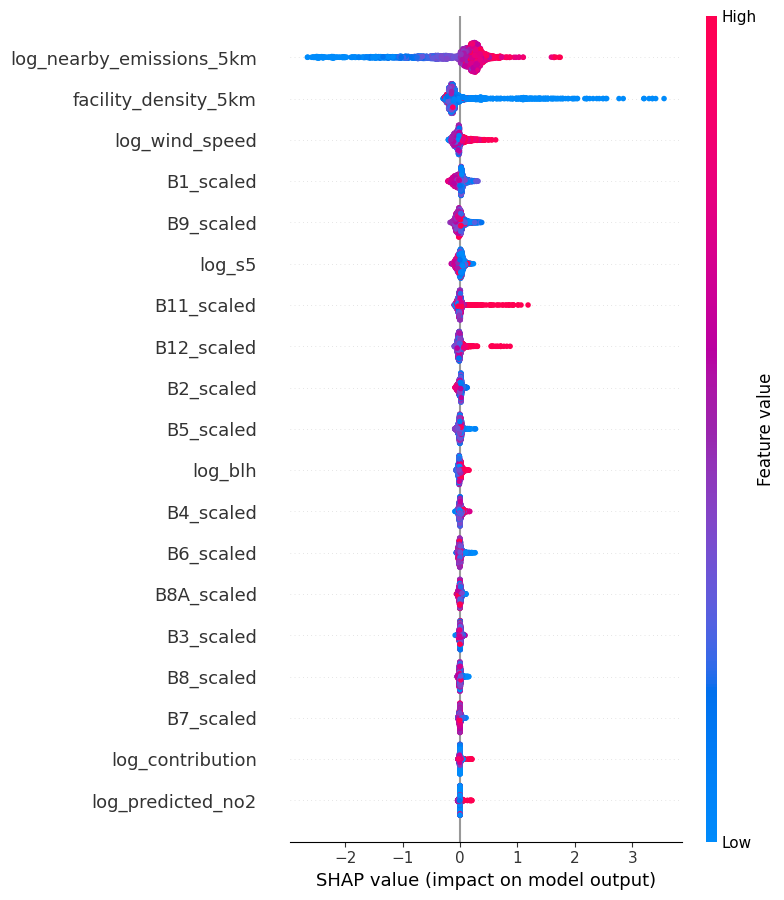

In [32]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

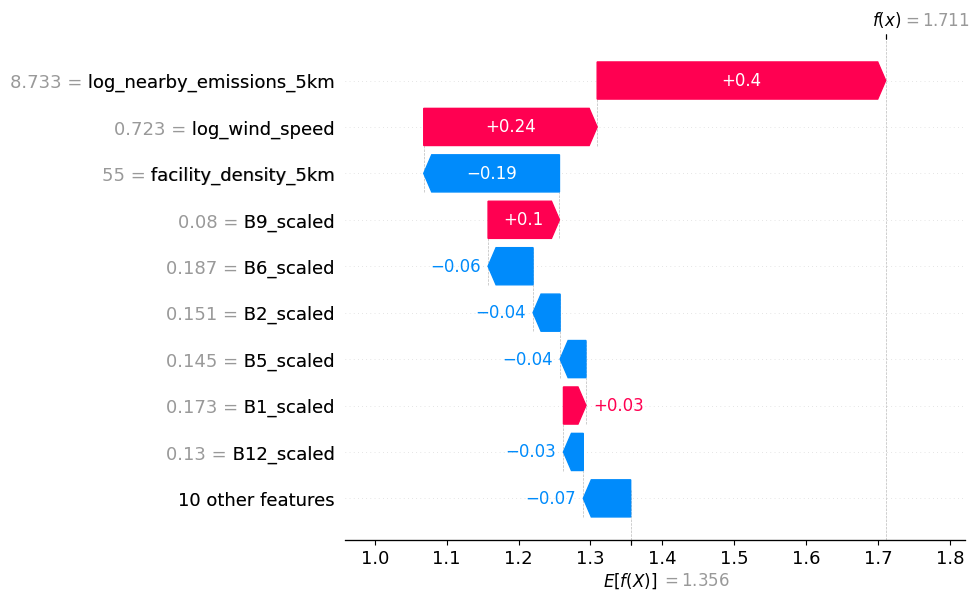

In [33]:
top_idx = (
    model_data_df
    .sort_values("risk_index", ascending=False)
    .index[0]
)

top_idx

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[top_idx],
        base_values=explainer.expected_value,
        data=X.iloc[top_idx],
        feature_names=X.columns
    )
)

### Other Checks

In [34]:
# Sector distribution
model_data_df.sort_values("risk_index", ascending=False)\
             .head(20)["naics_2digit"].value_counts()

naics_2digit
51    4
32    4
22    3
48    3
62    2
42    1
21    1
81    1
31    1
Name: count, dtype: int64

In [35]:
print("Corr risk vs log_emissions:",
      model_data_df["risk_index"]
      .corr(model_data_df["log_emissions"]))

print("Corr risk vs expected:",
      model_data_df["risk_index"]
      .corr(model_data_df["expected_log_emissions"]))

Corr risk vs log_emissions: -0.25093743651081274
Corr risk vs expected: 0.18243749675729734


In [36]:
print(
    model_data_df.loc[
        model_data_df["risk_index"] >= 90,
        "size_adjusted_residual"
    ].mean()
)

0.5852710245153258


### Visualizations

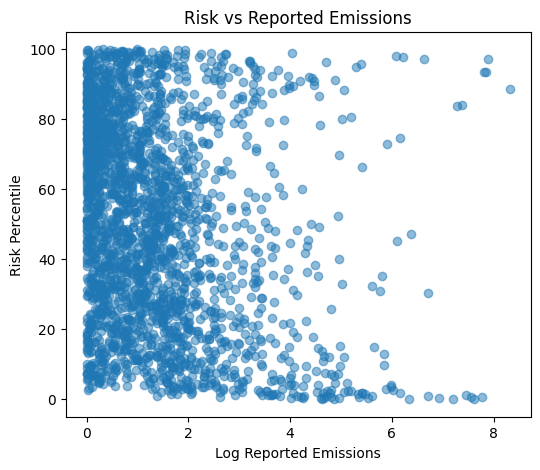

In [37]:
# Risk vs Reported Emissions
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(model_data_df["log_emissions"], 
            model_data_df["risk_index"],
            alpha=0.5)

plt.xlabel("Log Reported Emissions")
plt.ylabel("Risk Percentile")
plt.title("Risk vs Reported Emissions")
plt.show()

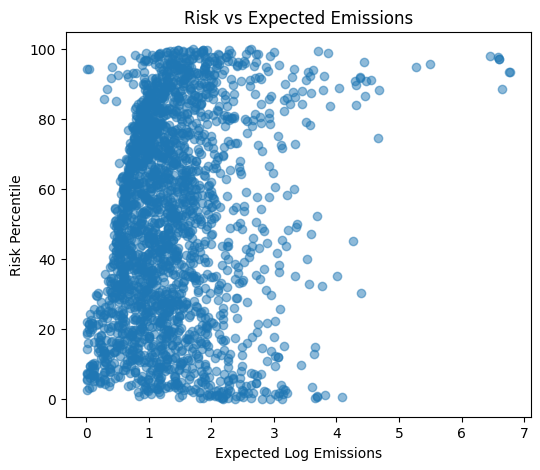

In [39]:
# Risk vs Expected Emissions
plt.figure(figsize=(6,5))
plt.scatter(model_data_df["expected_log_emissions"],
            model_data_df["risk_index"],
            alpha=0.5)

plt.xlabel("Expected Log Emissions")
plt.ylabel("Risk Percentile")
plt.title("Risk vs Expected Emissions")
plt.show()

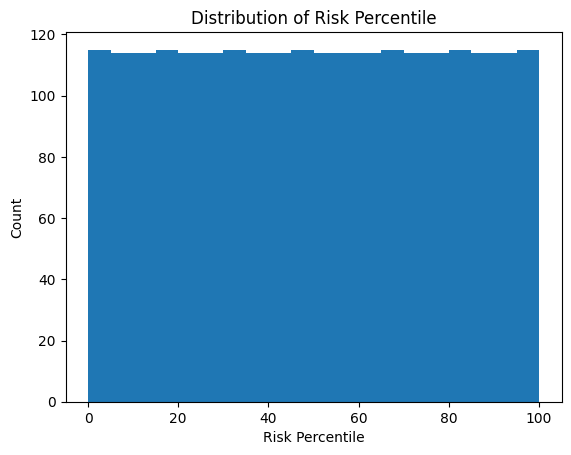

In [40]:
plt.hist(model_data_df["risk_index"], bins=20)
plt.title("Distribution of Risk Percentile")
plt.xlabel("Risk Percentile")
plt.ylabel("Count")
plt.show()

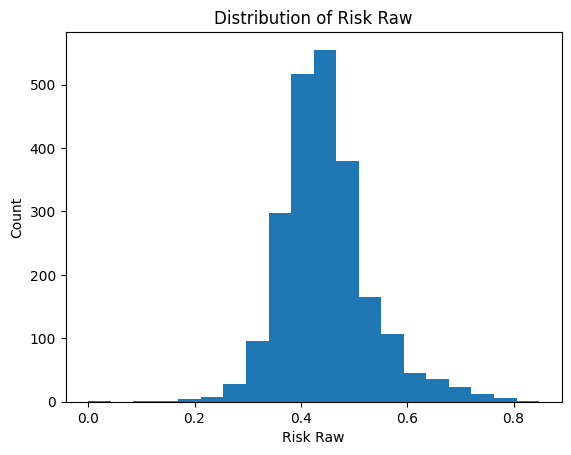

In [44]:
plt.hist(model_data_df["risk_raw"], bins=20)
plt.title("Distribution of Risk Raw")
plt.xlabel("Risk Raw")
plt.ylabel("Count")
plt.show()

## Save Results

In [46]:
model_data_df.columns

Index(['facility_id', 'predicted_no2_log', 'predicted_no2', 'naics_code',
       'lat', 'lon', 'GEOID10', 'reported_emissions', 'log_emissions',
       'background_s5', 'facility_density_5km', 'nearby_emissions_5km',
       'log_nearby_emissions_5km', 'boundary_layer_height',
       'u_component_of_wind_10m', 'v_component_of_wind_10m', 'wind_speed',
       'year', 'wind_dir', 'wind_dir_rad', 'wind_u_dir', 'wind_v_dir',
       'log_blh', 'log_wind_speed', 'B1', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5',
       'B6', 'B7', 'B8', 'B8A', 'B9', 'tropospheric_NO2_column_number_density',
       'facility_contribution', 'log_contribution', 'log_predicted_no2',
       'naics_2digit', 'sector_emission_mean', 'sector_emission_std',
       'sector_emission_z', 'emission_percentile', 'no2_percentile',
       'B1_scaled', 'B2_scaled', 'B3_scaled', 'B4_scaled', 'B5_scaled',
       'B6_scaled', 'B7_scaled', 'B8_scaled', 'B8A_scaled', 'B9_scaled',
       'B11_scaled', 'B12_scaled', 'log_s5', 'expected_log_e

In [47]:
# Create clean anomaly detection output
anomaly_output_df = model_data_df[[
    
    # Identifiers
    "facility_id",
    "lat",
    "lon",
    "naics_code",
    "naics_2digit",
    "GEOID10",
    
    # Emissions
    "reported_emissions",
    "log_emissions",
    "expected_log_emissions",
    "size_adjusted_residual",
    
    # Risk components
    "global_norm",
    "peer_norm",
    "atm_norm",
    "risk_raw",
    "risk_index"
    
]].copy()

In [48]:
# Rename risk components
anomaly_output_df = anomaly_output_df.rename(columns={
    "global_norm": "risk_global",
    "peer_norm": "risk_peer",
    "atm_norm": "risk_atmospheric",
    "risk_raw": "risk_score",
    "risk_index": "risk_percentile"
})

In [49]:
# Save Results
anomaly_output_df.to_csv(
    CONFIG["annual_anomaly_output"],
    index=False
)

print("Risk index saved successfully.")

Risk index saved successfully.
